# PyTorch, Tensors, and Backpropagation - Hands-on Practice

PyTorch is a library for:
- tensor computation (like NumPy on steroids)
- automatic differentiation (autograd)
- building neural networks
---

**🧠 Core idea**

> Deep learning is tensors + computation graphs + gradients.

In PyTorch:
- the **forward pass** builds a computation graph
- the **backward pass** propagates gradients through that graph

---

**🔁 What we will explore**

In this notebook we will:
1. Understand tensors and tensor operations
2. Learn how autograd tracks computations
3. See how backpropagation works step-by-step
4. Build and visualize a tiny neural network
5. Explore gradient flow using computation graphs and heatmaps

---

**🎯 Goal**

Know how to compute gradients with PyTorch and understand:
- how gradients flow
- how neural networks learn
- what happens internally during training

## Tensors

A tensor is a multidimensional array with extra powers:
- can run on GPU
- can track gradients

In [1]:
import torch

# Scalar (0D tensor)
a = torch.tensor(5.0)
print(a, a.shape)

# Vector (1D)
b = torch.tensor([1.0, 2.0, 3.0])
print(b, b.shape)

# Matrix (2D)
c = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(c, c.shape)

tensor(5.) torch.Size([])
tensor([1., 2., 3.]) torch.Size([3])
tensor([[1., 2.],
        [3., 4.]]) torch.Size([2, 2])


### Tensor filled with zeros

In [3]:
# Create a 3x3 tensor filled with zeros
zeros_tensor = torch.zeros(3, 3)
zeros_tensor

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

### Tensor filled with random values

In [5]:
# Create a 2x4 tensor with random values between 0 and 1
tensor_pytorch = torch.rand(2, 4)
tensor_pytorch

tensor([[0.3083, 0.3202, 0.8284, 0.4854],
        [0.0895, 0.3311, 0.8427, 0.1841]])

### Tensor operations (like NumPy)

In [2]:
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])

print(x + y)
print(x * y)
print(torch.dot(x, y))

tensor([5., 7., 9.])
tensor([ 4., 10., 18.])
tensor(32.)


PyTorch tensors behave like NumPy arrays, but can **remember how they were created**.
That is the key to backpropagation.

## Autograd - the magic

Autograd tracks operations to compute gradients automatically.

To enable it, set:
`requires_grad=True`

In [6]:
x = torch.tensor(2.0, requires_grad=True)

y = x**2 + 3*x + 1
print(y)

tensor(11., grad_fn=<AddBackward0>)


PyTorch has now built a **computation graph** behind the scenes.

### Backpropagation (computing gradient)

In [7]:
y.backward()
print(x.grad)

tensor(7.)


This is dy/dx.

For:
y = x² + 3x + 1  
dy/dx = 2x + 3

At x = 2 → 7

In [10]:
# another example y=x^3
x = torch.tensor(2.0, requires_grad=True)

y = x**3
print('y = x³       ', y)

y.backward()
print('dy/dx = 3x²  ', x.grad)

y = x³        tensor(8., grad_fn=<PowBackward0>)
dy/dx = 3x²   tensor(12.)


## Multiple tensors & chain rule

In [13]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)

c = a * b
d = c + b
d.backward()

print("d = ab + b:  ", d)
print("da = b:      ", a.grad)
print("db = a + 1:  ", b.grad)

d = ab + b:   tensor(9., grad_fn=<AddBackward0>)
da = b:       tensor(3.)
db = a + 1:   tensor(3.)


This demonstrates the **chain rule** used in neural networks.

In [14]:
# create tensor with requires_grad=True
x = torch.tensor([2.0, 3.0], requires_grad=True)

# perform several operations
y = x + 2
z = y ** 2 # z = z(y) = z(y(x)) = y**2 = (x+2)**2 = x**2 + 2*2*x + 4
result = z.sum()

# call backward
result.backward()

# receive gradients
print(x.grad)  # these are the derivatives of the function result with respect to x

tensor([ 8., 10.])


dz(x)/dx = 2*x + 4

x==2: 2*2 + 4 = 8

x==3: 2*3 + 4 = 10

## Build a neuron manually (no nn.Module)

A neuron does:

output = w * x + b

In [19]:
x = torch.tensor(4.0)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y = w * x + b
target = torch.tensor(20.0)

loss = (y - target) ** 2
loss.backward()

print("grad w:", w.grad)
print("grad b:", b.grad)

grad w: tensor(-88.)
grad b: tensor(-22.)


`L = (wx + b - t)^2`

`dL/dw = 2(wx + b - t)(x+0-0) = 2wx^2 + 2bx - 2tx = 2*2*16 + 2*1*4 - 2*20*4 = 64 + 8 - 160 = -88`

`dL/db = 2(wx + b - t)(0+1-0) = 2wx + 2b - 2t = 2*2*4 + 2*1 - 2*20 = 16 + 2 - 40 = -22`

This is EXACTLY what happens inside neural networks.

## Gradient Descent manually

Train a neuron **without any PyTorch high-level API**.

In [20]:
learning_rate = 0.01

for i in range(15):
    w.grad = None
    b.grad = None
    
    y = w * x + b
    loss = (y - target) ** 2
    
    loss.backward()
    
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
    
    print(f"Step {i}: loss={loss.item():.2f}")

Step 0: loss=121.00
Step 1: loss=52.71
Step 2: loss=22.96
Step 3: loss=10.00
Step 4: loss=4.36
Step 5: loss=1.90
Step 6: loss=0.83
Step 7: loss=0.36
Step 8: loss=0.16
Step 9: loss=0.07
Step 10: loss=0.03
Step 11: loss=0.01
Step 12: loss=0.01
Step 13: loss=0.00
Step 14: loss=0.00


### Same using nn.Module

In [21]:
import torch.nn as nn

model = nn.Linear(1, 1)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

x = torch.tensor([[4.0]])
target = torch.tensor([[20.0]])

for i in range(15):
    optimizer.zero_grad()
    
    output = model(x)
    loss = criterion(output, target)
    
    loss.backward()
    optimizer.step()
    
    print(f"Step {i}: loss={loss.item():.2f}")

Step 0: loss=261.08
Step 1: loss=113.73
Step 2: loss=49.54
Step 3: loss=21.58
Step 4: loss=9.40
Step 5: loss=4.09
Step 6: loss=1.78
Step 7: loss=0.78
Step 8: loss=0.34
Step 9: loss=0.15
Step 10: loss=0.06
Step 11: loss=0.03
Step 12: loss=0.01
Step 13: loss=0.01
Step 14: loss=0.00


/opt/miniconda3/envs/mlpeople7/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Inspect learned weights

In [22]:
for name, param in model.named_parameters():
    print(name, param.data)

weight tensor([[4.6701]])
bias tensor([1.2877])


# Visualizing computation graph

In [24]:
#!pip install torchviz

In [ ]:
# macOS
# !brew install graphviz

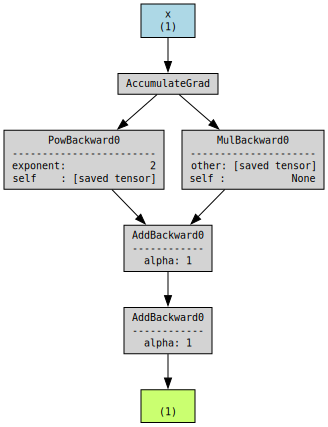

In [48]:
import torch
from torchviz import make_dot

x = torch.tensor([2.0], requires_grad=True)
y = x**2 + 3*x + 1

make_dot(y, params={"x": x}, show_attrs=True) #  show_attrs=True, show_saved=True)

## PyTorch Computation Graph Nodes (Autograd Basics)

When visualizing a PyTorch computation graph (e.g. with `torchviz`), you may see nodes like:

- `AddBackward0`
- `MulBackward0`
- `PowBackward0`
- `AccumulateGrad`

These are **internal gradient functions** created by PyTorch’s autograd engine.

---

**Core Idea**

PyTorch builds a graph of:
- **forward operations** (math)
- **backward functions** (gradients)

Backpropagation = traversing this graph in reverse.

---

### ➕ AddBackward0

```python
z = a + b
````

Gradient:

```
dz/da = 1
dz/db = 1
```

---

### ✖️ MulBackward0

```python
z = a * b
```

Gradient:

```
dz/da = b
dz/db = a
```

---

### 🔺 PowBackward0

```python
y = x^2
```

Gradient:

```
dy/dx = 2x
```

---

### 📦 AccumulateGrad

Appears for **leaf tensors**:

```python
x = torch.tensor(..., requires_grad=True)
```

Meaning:

* this is a model input/parameter
* gradients are stored in `.grad`

---

**⚡ Key Insight**

Each node:

* represents a differentiable operation
* knows how to compute its gradient
* is used during backpropagation

---

**🧠 Mental Model**

* Forward pass → build graph
* Backward pass → apply chain rule on graph



# Forward vs Backward in PyTorch (Visual Walkthrough)

We will:
1. Build a simple function
2. Show forward computation step-by-step
3. Run backward
4. Trace gradients step-by-step

Function:
y = x² + 3x + 1

## ▶️ FORWARD PASS (step-by-step)

In [58]:
x = torch.tensor(2.0, requires_grad=True)

# Step 1: x²
a = x**2
print("a = x^2 =", a.item())

# Step 2: 3x
b = 3 * x
print("b = 3x =", b.item())

# Step 3: sum parts
c = a + b
print("c = x^2 + 3x =", c.item())

# Step 4: final output
y = c + 1
print("y =", y.item())

a = x^2 = 4.0
b = 3x = 6.0
c = x^2 + 3x = 10.0
y = 11.0


## 🔙 3. BACKWARD PASS (gradient animation)

In [59]:
# Step 1: trigger backprop
y.backward()

# Step 2: gradient at final node
print("dy/dx =", x.grad)

dy/dx = tensor(7.)



---

### 🔁 Step-by-step backward flow

**What happened internally?**

We now reconstruct the chain:

1. Start at output

```text id="fw9_chain1"
y = c + 1
dy/dc = 1
```

---

2. Split into branches

```text id="fw10_chain2"
c = a + b
dc/da = 1
dc/db = 1
```

---

3. Go deeper

```text id="fw11_chain3"
a = x²   → da/dx = 2x
b = 3x   → db/dx = 3
```

---

4. Combine gradients

```text id="fw12_chain4"
dy/dx = 2x + 3
```

At x = 2:

```text id="fw13_result"
dy/dx = 4 + 3 = 7
```

---

4. “Animation summary view”

```markdown id="fw14_summary"
FORWARD:
x → x² → + → + → y

BACKWARD:
y → + → + → x → x

Gradient flows backward like water through pipes.
```

---

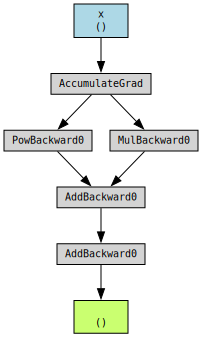

In [60]:
from torchviz import make_dot

make_dot(y, params={"x": x})

- Forward pass = building computation
- Backward pass = reversing computation
- Each node applies its local derivative
- PyTorch automates chain rule perfectly

## More Visualization Examples 

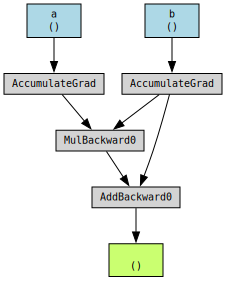

In [57]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)

c = a * b
d = c + b

make_dot(d, params={"a": a, "b": b}) # , show_attrs=True, show_saved=True

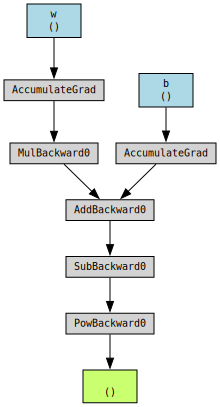

In [62]:
x = torch.tensor(4.0)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y = w * x + b
target = torch.tensor(20.0)
loss = (y - target) ** 2

make_dot(loss, params={"w": w, "b": b}) # , show_attrs=True

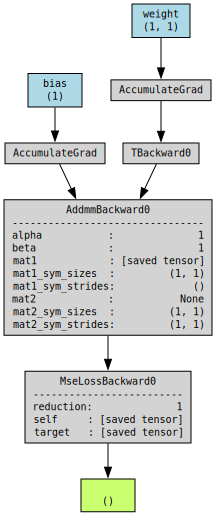

In [53]:
import torch.nn as nn

model = nn.Linear(1, 1)

x = torch.tensor([[4.0]])
target = torch.tensor([[20.0]])

criterion = nn.MSELoss()

output = model(x)
loss = criterion(output, target)

make_dot(loss, params=dict(model.named_parameters()), show_attrs=True)

# 2-Layer Neural Network: Forward + Backward Visualization

We will:

* build a tiny Multilayer Perceptron (MLP) from scratch
* compute forward pass manually
* run backward pass with PyTorch autograd
* visualize computation flow step-by-step (matplotlib animation style)

## 🧱 1. Problem setup

We define a tiny network:

$
x \rightarrow (Linear 1) \rightarrow ReLU \rightarrow (Linear 2) \rightarrow y
$

---

In [70]:
import torch
import matplotlib.pyplot as plt
import networkx as nx
import time

## 🧠 2. Define a 2-layer neural network

We keep it minimal:

In [71]:
torch.manual_seed(0)

# input
x = torch.tensor([[2.0]], requires_grad=True)

# layer 1
W1 = torch.tensor([[1.0]], requires_grad=True)
b1 = torch.tensor([[0.5]], requires_grad=True)

# layer 2
W2 = torch.tensor([[1.5]], requires_grad=True)
b2 = torch.tensor([[0.0]], requires_grad=True)

## ⚙️ 3. Forward pass (manual computation)

In [72]:
z1 = x @ W1 + b1
a1 = torch.relu(z1)
y = a1 @ W2 + b2

target = torch.tensor([[5.0]])
loss = (y - target) ** 2

loss

tensor([[1.5625]], grad_fn=<PowBackward0>)

## 🧠 4. Build computation graph (visual structure)

We define nodes:

In [73]:
nodes = {
    "x": (0, 0),

    "z1": (1, 1),
    "a1 (ReLU)": (2, 1),

    "z2": (3, 0),
    "y": (4, 0),

    "loss": (5, 0)
}

edges = [
    ("x", "z1"),
    ("z1", "a1 (ReLU)"),
    ("a1 (ReLU)", "z2"),
    ("z2", "y"),
    ("y", "loss")
]

## 🎨 5. Visualization helper


In [74]:
def draw(step_nodes, title=""):
    G = nx.DiGraph()
    G.add_edges_from(edges)

    plt.figure(figsize=(7, 3))

    nx.draw(
        G,
        nodes,
        with_labels=True,
        node_size=2500,
        node_color=[
            "orange" if n in step_nodes else "lightgray"
            for n in G.nodes
        ],
        arrows=True
    )

    plt.title(title)
    plt.show()

## ▶️ 6. FORWARD PASS ANIMATION

We reveal activations step-by-step:

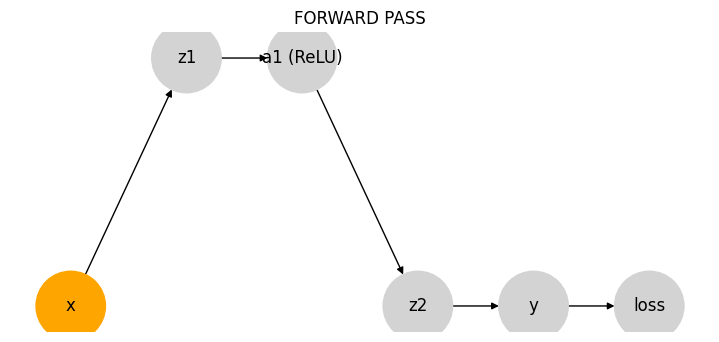

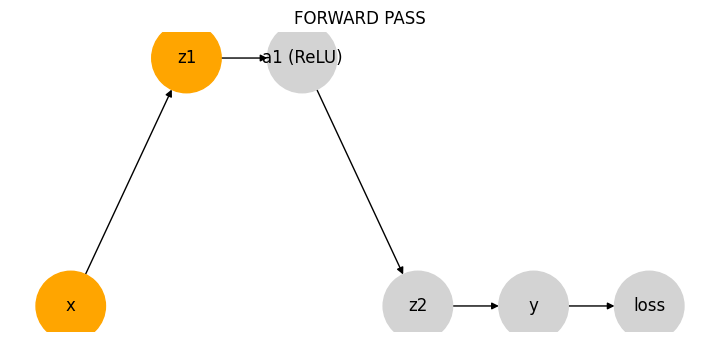

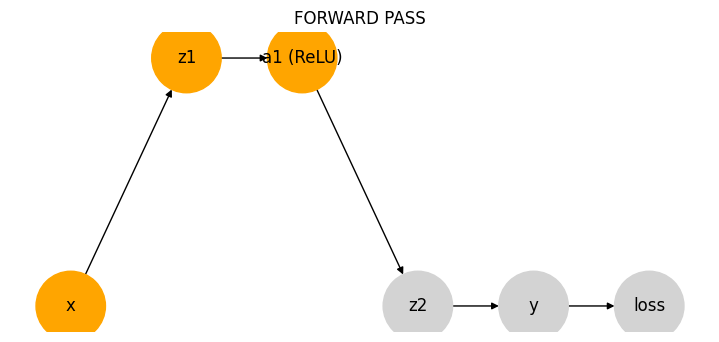

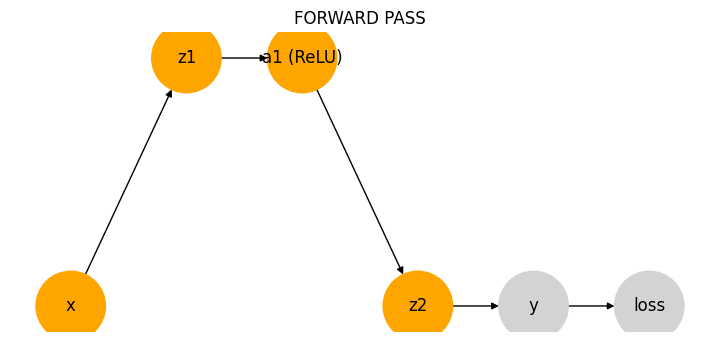

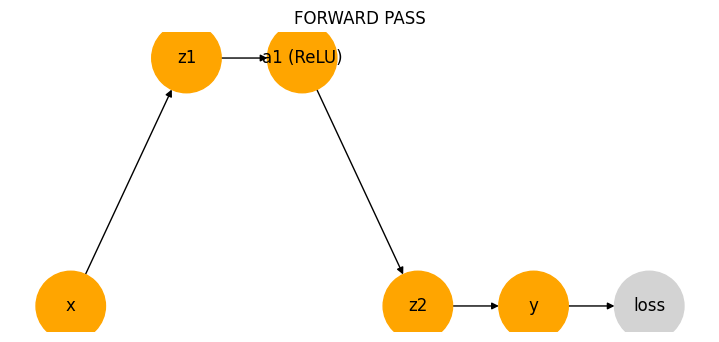

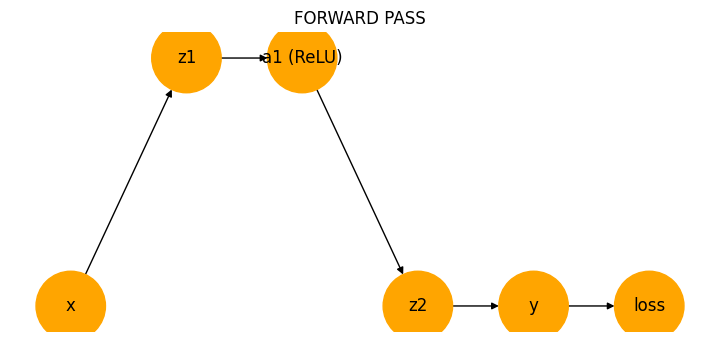

In [75]:
forward_steps = [
    ["x"],
    ["x", "z1"],
    ["x", "z1", "a1 (ReLU)"],
    ["x", "z1", "a1 (ReLU)", "z2"],
    ["x", "z1", "a1 (ReLU)", "z2", "y"],
    ["x", "z1", "a1 (ReLU)", "z2", "y", "loss"]
]

for s in forward_steps:
    draw(s, "FORWARD PASS")
    time.sleep(1)

## 🔙 7. BACKWARD PASS (AUTOGRAD)

Now we compute gradients:

In [76]:
loss.backward()

## 🧠 8. BACKWARD VISUALIZATION (gradient flow)

We reverse activation flow:

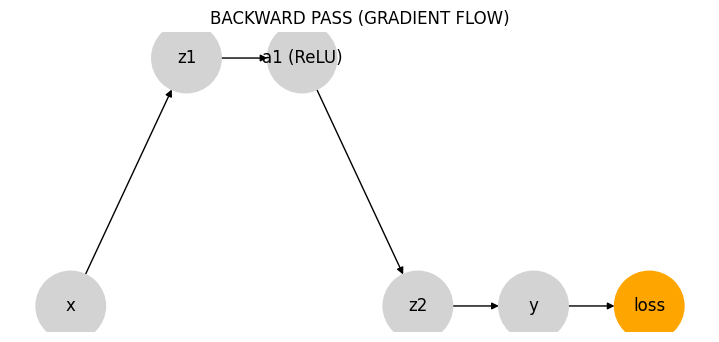

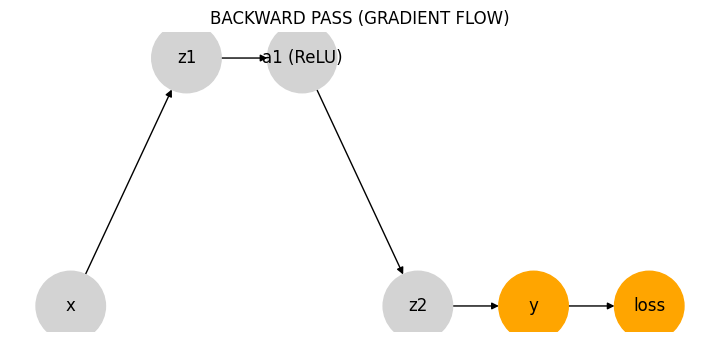

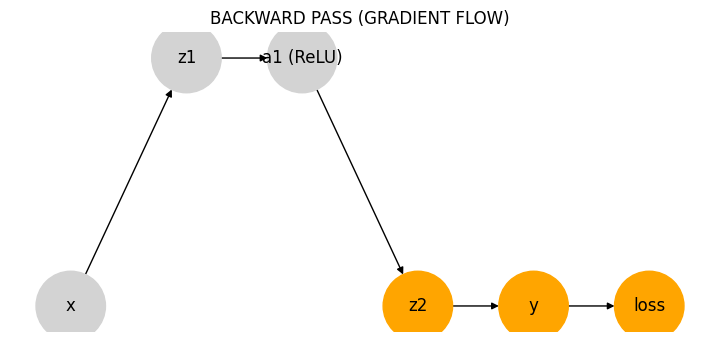

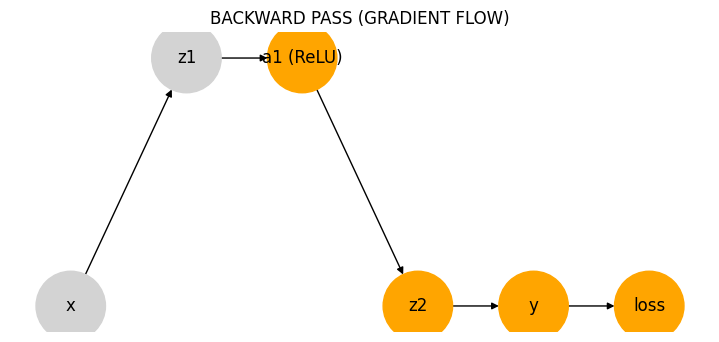

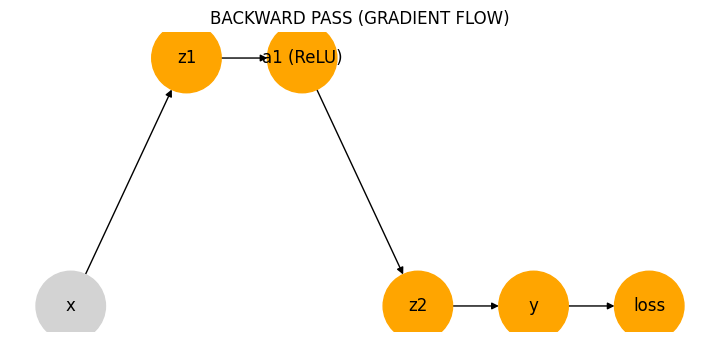

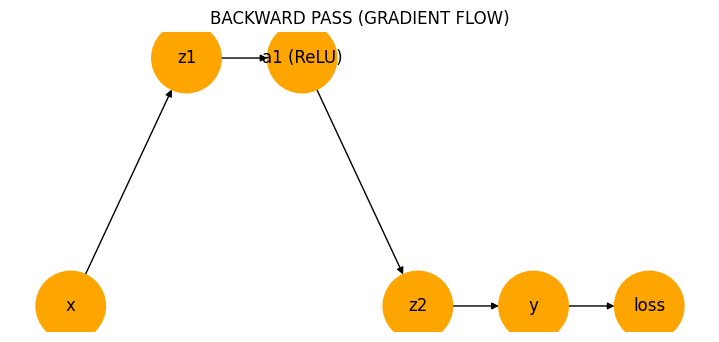

In [77]:
backward_steps = [
    ["loss"],
    ["loss", "y"],
    ["loss", "y", "z2"],
    ["loss", "y", "z2", "a1 (ReLU)"],
    ["loss", "y", "z2", "a1 (ReLU)", "z1"],
    ["loss", "y", "z2", "a1 (ReLU)", "z1", "x"]
]

for s in backward_steps:
    draw(s, "BACKWARD PASS (GRADIENT FLOW)")
    time.sleep(1)

## 🔥 9. Inspect real gradients

Now connect visualization with reality:

In [78]:
print("dLoss/dW2:", W2.grad)
print("dLoss/dW1:", W1.grad)
print("dLoss/dx:", x.grad)

dLoss/dW2: tensor([[-6.2500]])
dLoss/dW1: tensor([[-7.5000]])
dLoss/dx: tensor([[-3.7500]])


## 🧠 Review

### Forward pass

```

x → Linear → ReLU → Linear → loss

```

This is the process of computing predictions and measuring error.

---

### Backward pass

```

loss → Linear → ReLU → Linear → x

```

This is not a second computation of values, but the flow of **gradients (error signals)** back through the same operations.

---

## ⚡ Key intuition

| Stage         | Meaning                                                                 |
| ------------- | ----------------------------------------------------------------------- |
| Forward       | Computes predictions from inputs                                        |
| Backward      | Propagates gradients (error signals) back through the network          |
| ReLU          | Gates gradients (blocks or passes them depending on activation)        |
| Linear layers | Redistribute gradients through weights using the chain rule            |

---

## 🧠 What this means

This visualization shows:

- how a neural network transforms input data into predictions  
- how errors flow backward through the same computational path  
- how each weight receives a “responsibility signal” (gradient) indicating how it should change to reduce loss  

---

## 🔥 Key takeaway

> Forward pass answers: *“What does the model predict?”*  
> Backward pass answers: *“Who is responsible for the error, and by how much?”*


# Gradient heatmap visualization
## Basic weight gradient heatmap (Linear layer)

This is the simplest and most important case.

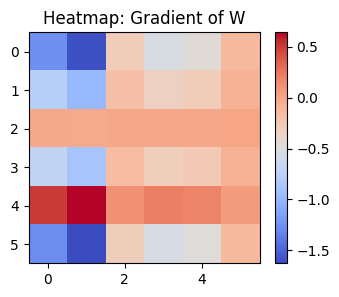

In [81]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)

# simple linear layer
W = torch.randn(6, 6, requires_grad=True)

x = torch.randn(1, 6)
target = torch.randn(1, 6)

# forward
y = x @ W
loss = (y - target).pow(2).mean()

# backward
loss.backward()

# heatmap
plt.figure(figsize=(4, 3))
plt.imshow(W.grad.detach(), cmap="coolwarm")
plt.colorbar()
plt.title("Heatmap: Gradient of W")
plt.show()

**🧠 What you are seeing**

* Each cell = how much that weight wants to change
* Red = increase weight
* Blue = decrease weight
* White ≈ no learning signal



## 🔥 2. Gradient heatmap across training steps

Now we see how gradients evolve.

Each heatmap shows the gradient of the weight matrix at a given step, i.e.:
> how much each weight wants to change at that moment.

By comparing steps, we can observe whether training is:
- unstable (large, noisy gradients)
- stabilizing (structured gradients)
- converging (small gradients approaching zero)

In [166]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(1)

W = torch.randn(8, 8, requires_grad=True)

x = torch.randn(64, 8)
target = torch.randn(64, 8)

heatmaps = []
lr = 0.05

for step in range(100):

    # forward
    y = x @ W
    loss = (y - target).pow(2).mean()

    # reset grads BEFORE backward
    if W.grad is not None:
        W.grad.zero_()

    loss.backward()

    # store gradients
    if step % 10 == 0:
        heatmaps.append(W.grad.detach().clone())
        print(f'loss: {loss}')

    # update
    with torch.no_grad():
        W -= lr * W.grad

loss: 9.918676376342773
loss: 7.561995029449463
loss: 5.866440773010254
loss: 4.639255046844482
loss: 3.7453582286834717
loss: 3.0897631645202637
loss: 2.605426788330078
loss: 2.2448415756225586
loss: 1.9742021560668945
loss: 1.7693443298339844


In [167]:
# normalize - compute global scale
all_grads = torch.stack(heatmaps)
vmax = all_grads.abs().max().item()

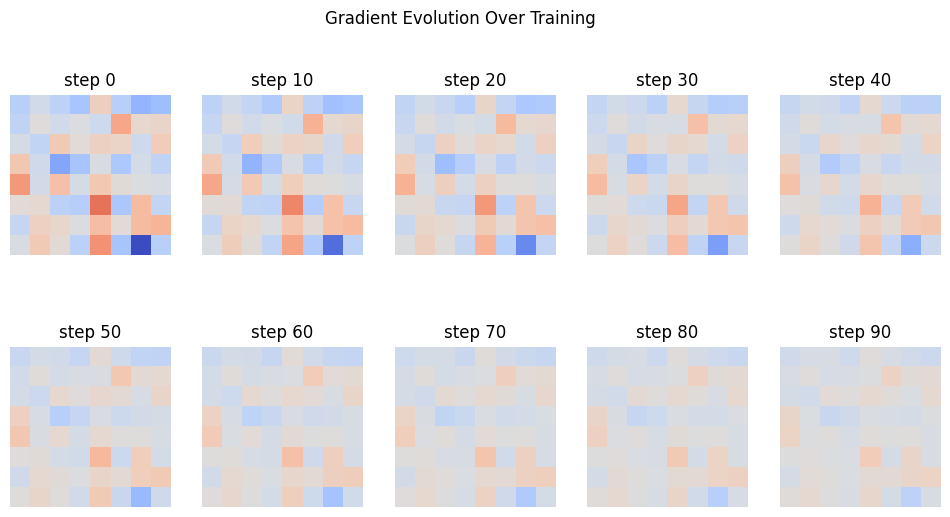

In [168]:
fig, axes = plt.subplots(2, int(len(heatmaps) / 2), figsize=(12, 6))

axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(
        heatmaps[i],
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax
    )
    ax.set_title(f"step {i*10}")
    ax.axis("off")

plt.suptitle("Gradient Evolution Over Training")
plt.show()